[[7, 0, {'weight': 3.2, 'required': 1}], [1, 0, {'weight': 3.1, 'required': 0}], [4, 0, {'weight': 2.2, 'required': 0}], [10, 7, {'weight': 0.5, 'required': 1}], [12, 10, {'weight': 1.2, 'required': 1}], [25, 18, {'weight': 1.3, 'required': 1}], [20, 18, {'weight': 1.9, 'required': 1}], [24, 25, {'weight': 0.1, 'required': 1}], [10, 5, {'weight': 1.3, 'required': 1}], [9, 5, {'weight': 0.7, 'required': 1}], [14, 12, {'weight': 1.5, 'required': 0}], [21, 19, {'weight': 0.3, 'required': 1}], [22, 21, {'weight': 1.3, 'required': 1}], [23, 21, {'weight': 0.5, 'required': 1}], [17, 22, {'weight': 0.9, 'required': 1}], [23, 22, {'weight': 1.4, 'required': 1}], [18, 17, {'weight': 0.3, 'required': 1}], [27, 20, {'weight': 1.4, 'required': 0}], [8, 3, {'weight': 1.3, 'required': 1}], [5, 3, {'weight': 1.5, 'required': 1}], [11, 8, {'weight': 0.6, 'required': 1}], [9, 8, {'weight': 1.9, 'required': 1}], [19, 11, {'weight': 2.5, 'required': 1}], [2, 1, {'weight': 0.7, 'required': 1}], [3, 2, {'w

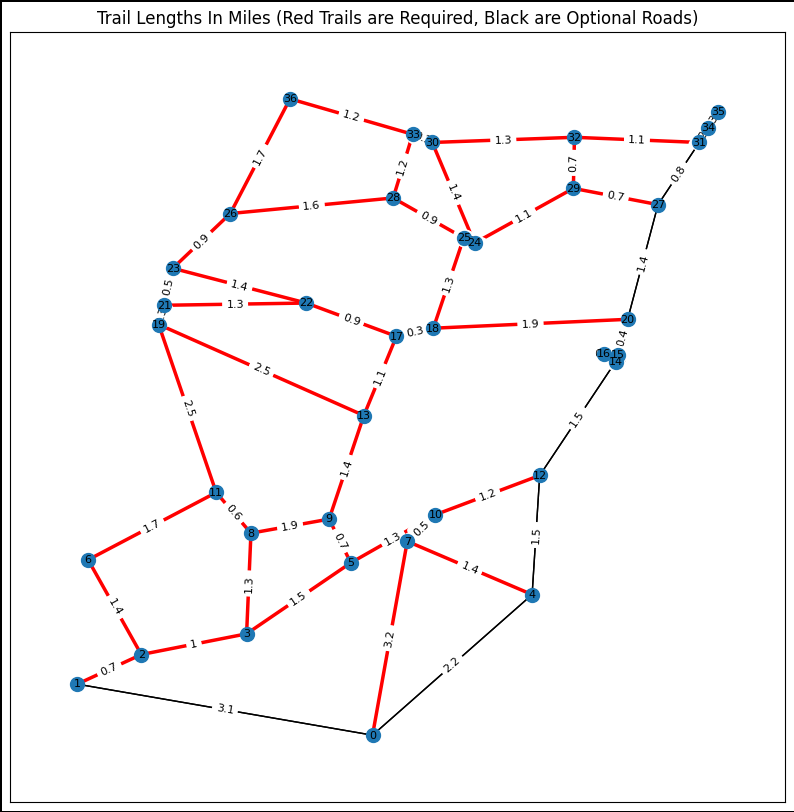

In [264]:
%run BuildGraph.ipynb

In [265]:
from gurobipy import *
import imageio
import itertools as it

# Create a new model
m = Model()

In [266]:
'''def edgeName(u,v,reversed = False):
    if(reversed):
        return str(v) + "_" + str(u) if u < v else str(u) + "_" + str(v)
    else:
        return str(u) + "_" + str(v) if u < v else str(v) + "_" + str(u)
'''

'def edgeName(u,v,reversed = False):\n    if(reversed):\n        return str(v) + "_" + str(u) if u < v else str(u) + "_" + str(v)\n    else:\n        return str(u) + "_" + str(v) if u < v else str(v) + "_" + str(u)\n'

In [267]:
#for each edge, create a variable in the model
gurobiVars = dict()
obj = LinExpr()

for u,v,a in G.edges(data=True):
    thisEdgeName = str(u) + "_" + str(v)
    thisVar = m.addVar(vtype=GRB.INTEGER, name=thisEdgeName)
    gurobiVars[thisEdgeName] = thisVar
    obj += (a['weight'] * (thisVar))
    
m.setObjective(obj, GRB.MINIMIZE)

In [268]:
#Constraints: all required trails must be hiked in at least one of their two directions
for u,v,a in G.edges(data=True):
    if(a['required']==1):
        constraintForThisEdge = LinExpr()
        
        constraintForThisEdge += gurobiVars[str(u) + "_" + str(v)]
        constraintForThisEdge += gurobiVars[str(v) + "_" + str(u)]

        m.addConstr(constraintForThisEdge >= 1)

In [269]:
#A eulerian tour requires (and will always exist if) 
# all nodes are even 

#to do this, iterate over all nodes. Create a constraint that the total
# number of paths for all edges going into or out of that node must be even.



#here's the original code, for an undirected graph
#Gurobi doesn't allow modulo operator
#  so to solve that, declare a dedicated int variable for each
#constraint, and then express each constraint in the form X + Y = 2z (for evenness)
#that thisNodeEvenOddVar doesn't matter for the outcome, it will just constrain to even
'''
for n in G.nodes():
    constraintForThisNode = LinExpr()
    thisNodeEvenOddVar = m.addVar(vtype=GRB.INTEGER, name="EvennessForNode" + str(n))
    for u,v,a in G.edges(n, data=True):
        constraintForThisNode += gurobiVars[str(u) + "_" + str(v)]
    m.addConstr(constraintForThisNode == (2*thisNodeEvenOddVar))
'''

#I ended up making this a directed graph, which was a bit easier to build.
#I can calculate each node's in-degree and out-degree independently
#and then they need to be equal to each other.
for n in G.nodes():
    inDegreeThisNode = LinExpr()
    outDegreeThisNode = LinExpr()
    for u,v,a in G.edges(n, data=True):
        #is this edge going into our node or out?
        outDegreeThisNode += gurobiVars[str(u) + "_" + str(v)]
    for u,v,a in G.in_edges(n, data=True):
        inDegreeThisNode += gurobiVars[str(u) + "_" + str(v)]


    m.addConstr(inDegreeThisNode == outDegreeThisNode)

In [270]:
# Subtours

# There is a proper way to do this documented here: 
# https://colab.research.google.com/github/Gurobi/modeling-examples/blob/master/traveling_salesman/tsp.ipynb#scrollTo=MuqBd8AdLYAC
# but it's complicated.

# actually didn't end up needing to do any subtour elimination.


In [271]:
#do the thing
m.optimize()

Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (linux64 - "Ubuntu 24.04.4 LTS")

CPU model: AMD Ryzen 7 9700X 8-Core Processor, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 81 rows, 104 columns and 296 nonzeros (Min)
Model fingerprint: 0x453cfe26
Model has 104 linear objective coefficients
Variable types: 0 continuous, 104 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [1e-01, 3e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]

Found heuristic solution: objective 98.0000000
Presolve removed 4 rows and 4 columns
Presolve time: 0.00s
Presolved: 77 rows, 100 columns, 284 nonzeros
Variable types: 0 continuous, 100 integer (0 binary)

Root relaxation: objective 4.930000e+01, 77 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntI

In [272]:
#this would output all of the constraints in the model so that I can confirm that
#they got created correctly.

m.display()

Minimize
3.2 0_7 + 3.1 0_1 + 2.2 0_4 + 0.5 7_10 + 3.2 7_0 + 1.4 7_4 + 1.2 10_12 + 0.5 10_7
+ 1.3 10_5 + 1.3 18_25 + 1.9 18_20 + 0.3 18_17 + 0.1 25_24 + 1.3 25_18 + 0.9 25_28
+ 1.3 5_10 + 0.7 5_9 + 1.5 5_3 + 1.5 12_14 + 1.2 12_10 + 1.5 12_4 + 0.3 19_21
+ 2.5 19_11 + 2.5 19_13 + 1.3 21_22 + 0.5 21_23 + 0.3 21_19 + 0.9 22_17 + 1.4 22_23
+ 1.3 22_21 + 0.3 17_18 + 0.9 17_22 + 1.1 17_13 + 1.4 20_27 + 1.9 20_18 + 0.4 20_15
+ 1.3 3_8 + 1.5 3_5 + 3_2 + 0.6 8_11 + 1.9 8_9 + 1.3 8_3 + 2.5 11_19 + 0.6 11_8
+ 1.7 11_6 + 0.7 1_2 + 3.1 1_0 + 2_3 + 1.4 2_6 + 0.7 2_1 + 1.4 9_13 + 0.7 9_5 + 1.9 9_8
+ 1.1 13_17 + 2.5 13_19 + 1.4 13_9 + 0.7 27_29 + 0.8 27_31 + 1.4 27_20 + 0.7 29_32
+ 0.7 29_27 + 1.1 29_24 + 1.4 24_30 + 1.1 24_29 + 0.1 24_25 + 0.2 30_33 + 1.3 30_32
+ 1.4 30_24 + 1.2 33_36 + 0.2 33_30 + 1.2 33_28 + 1.2 36_33 + 1.7 36_26 + 0.7 32_29
+ 1.3 32_30 + 1.1 32_31 + 1.1 31_32 + 0.2 31_34 + 0.8 31_27 + 1.2 28_33 + 0.9 28_25
+ 1.6 28_26 + 0.9 23_26 + 0.5 23_21 + 1.4 23_22 + 1.7 26_36 + 1.6 26_28 + 0.9

/tmp/ipykernel_3991869/3677588067.py:4: DeprecationWarning: Model.display() is deprecated
  m.display()


In [273]:
#print the results, sorted by variable name
#I spent a lot of time staring at this and tweaking the constraints to make
#sure I believed in the results.

vList = m.getVars()
vList.sort(key=lambda var: int(var.varName[:var.varName.find("_",0)]) if var.varName.find("_",0) > 0 else 1000 )


for v in vList:
    print('%s %g' % (v.varName, v.x))

print('Obj: %g' % m.objVal)

0_7 -0
0_1 -0
0_4 1
1_2 1
1_0 -0
2_3 1
2_6 -0
2_1 1
3_8 1
3_5 1
3_2 -0
4_7 1
4_12 -0
4_0 -0
5_10 -0
5_9 1
5_3 1
6_11 -0
6_2 1
7_10 1
7_0 1
7_4 -0
8_11 1
8_9 1
8_3 -0
9_13 2
9_5 -0
9_8 -0
10_12 -0
10_7 1
10_5 1
11_19 -0
11_8 1
11_6 1
12_14 -0
12_10 1
12_4 -0
13_17 1
13_19 1
13_9 -0
14_16 0
14_15 -0
14_12 1
15_20 -0
15_14 -0
15_16 1
16_15 0
16_14 1
17_18 2
17_22 -0
17_13 -0
18_25 1
18_20 1
18_17 -0
19_21 1
19_11 1
19_13 -0
20_27 -0
20_18 -0
20_15 1
21_22 -0
21_23 1
21_19 1
22_17 1
22_23 -0
22_21 1
23_26 -0
23_21 -0
23_22 2
24_30 1
24_29 -0
24_25 1
25_24 1
25_18 -0
25_28 1
26_36 -0
26_28 1
26_23 1
27_29 -0
27_31 1
27_20 -0
28_33 1
28_25 -0
28_26 1
29_32 -0
29_27 1
29_24 1
30_33 1
30_32 1
30_24 -0
31_32 1
31_34 1
31_27 -0
32_29 2
32_30 -0
32_31 -0
33_36 1
33_30 1
33_28 -0
34_35 1
34_31 1
35_34 1
36_33 -0
36_26 1
Obj: 63.5


In [274]:
#so the answer is that if you do it all in one trip, the total mileage would be
# 63.5. The total mileage of the trails by themselves is 48.5, so the complete
#tour requires 15 miles of doubling back/walking on roads

In [275]:
#update the graph that I built before. Add a new attribute to each edge called
# "trips" that shows how many times we need to traverse. I'll eventually expand
# this into a multidigraph. 

for u,v,a in G.edges(data=True):
    for var in vList:
        if(var.varName == f'{u}_{v}'):
            a['trips'] = abs(var.x)



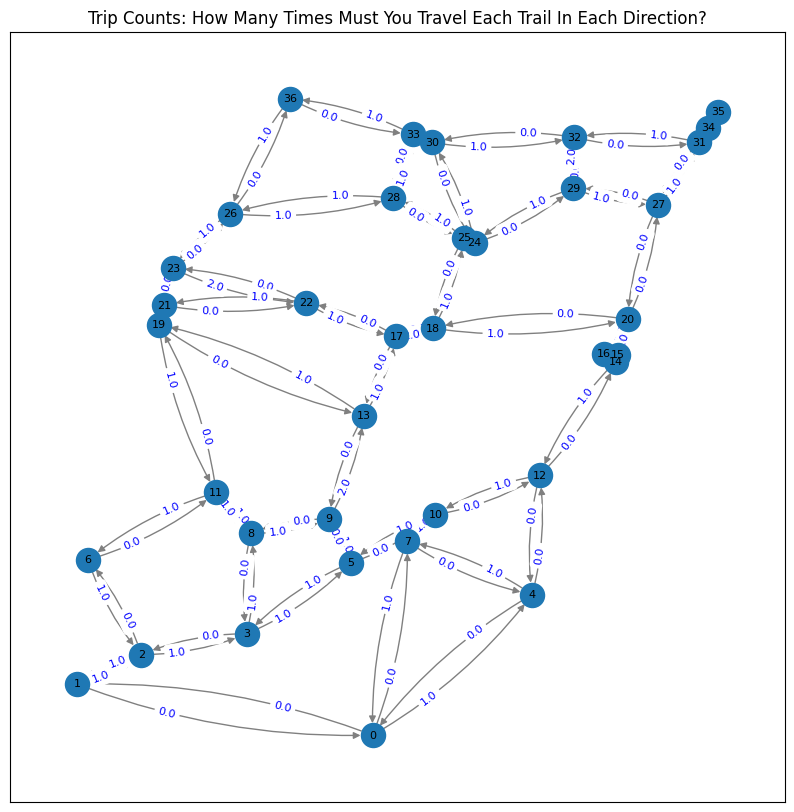

In [276]:
#This code based on the example provided by NetworkX
# https://networkx.org/documentation/stable/auto_examples/drawing/plot_multigraphs.html

def draw_labeled_multigraph(G, attr_name, ax=None):
    """
    Length of connectionstyle must be at least that of a maximum number of edges
    between pair of nodes. This number is maximum one-sided connections
    for directed graph and maximum total connections for undirected graph.
    """
    # Works with arc3 and angle3 connectionstyles
    connectionstyle = [f"arc3,rad={r}" for r in it.accumulate([0.1] * 4)]
    # connectionstyle = [f"angle3,angleA={r}" for r in it.accumulate([30] * 4)]

    pos = nodes
    nx.draw_networkx_nodes(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    nx.draw_networkx_edges(
        G, pos, edge_color="grey", connectionstyle=connectionstyle, ax=ax
    )

    labels = {
        tuple(edge): f"{attrs[attr_name]}"
        for *edge, attrs in G.edges(data=True)
    }
    
    nx.draw_networkx_edge_labels(
        G,
        pos,
        labels,
        connectionstyle=connectionstyle,
        label_pos=0.3,
        font_color="blue",
        #bbox={"alpha": 0},
        ax=ax,
        font_size=8
    )
    

plt.figure(1,figsize=(10,10), edgecolor='black')
plt.title(f"Trip Counts: How Many Times Must You Travel Each Trail In Each Direction?")
draw_labeled_multigraph(G, "trips", None)
plt.savefig("trip_counts.png", bbox_inches="tight")
plt.show()

In [277]:
#now build the tour
#I struggled with this part at first. 
# I tried writing my own algorithm and it wasn't working.
# turns out that NetworkX has an eulerian_circuit() function built in =)
def expand_graph_by_trips(G):
    H = nx.MultiDiGraph()

    # copy nodes (and optionally node attributes)
    H.add_nodes_from(G.nodes(data=True))

    for u, v, data in G.edges(data=True):
        trips = int(data.get('trips', 1))

        for _ in range(trips):
            # add one edge per trip
            H.add_edge(u, v)

    return H

H = expand_graph_by_trips(G)

if(not nx.is_eulerian(H)):
   print("ERROR - the graph should be eulerian at this point")

circuit = list(nx.eulerian_circuit(H, source=31))

print(circuit)

[(31, 34), (34, 35), (35, 34), (34, 31), (31, 32), (32, 29), (29, 24), (24, 25), (25, 28), (28, 26), (26, 28), (28, 33), (33, 30), (30, 33), (33, 36), (36, 26), (26, 23), (23, 22), (22, 21), (21, 19), (19, 11), (11, 8), (8, 11), (11, 6), (6, 2), (2, 1), (1, 2), (2, 3), (3, 5), (5, 3), (3, 8), (8, 9), (9, 13), (13, 17), (17, 18), (18, 20), (20, 15), (15, 16), (16, 14), (14, 12), (12, 10), (10, 7), (7, 0), (0, 4), (4, 7), (7, 10), (10, 5), (5, 9), (9, 13), (13, 19), (19, 21), (21, 23), (23, 22), (22, 17), (17, 18), (18, 25), (25, 24), (24, 30), (30, 32), (32, 29), (29, 27), (27, 31)]


In [278]:
#ChatGPT helped me with this part
#the goal is to use plt to draw each step of the tour as a separate image,
#and then stitch those images into a gif. In the gif, only the newest edge
#will be red (to make it more obvious). All the older edges will be grey

def animate_eulerian(G, pos, circuit, out_file="tour.gif"):
    frames = []
    visited_edges = []
    connectionstyle = [f"arc3,rad={r}" for r in it.accumulate([0.1] * 4)]

    for i, (u, v) in enumerate(circuit):
        fig, ax = plt.subplots(figsize=(10, 10))
        ax.set_xlim(180, 800)
        ax.set_ylim(28000, 29000) #unclear why the y coordinates ended up
                                  #with these values. In the `nodes` array, the range is 0-1300
        ax.set_aspect('equal')
        #ax.axis("off")
        ax.set_title(f"Dolly Sods Optimal Tour (Step {i+1}: {u} → {v})")

        # Draw nodes
        nx.draw_networkx_nodes(G, pos, ax=ax,node_size=100)
        nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)

        # Draw previously visited edges in grey
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=visited_edges,
            connectionstyle=connectionstyle,
            edge_color="grey",
            ax=ax
        )

        # Draw current edge in red
        nx.draw_networkx_edges(
            G,
            pos,
            edgelist=[(u, v)],
            edge_color="red",
            connectionstyle=connectionstyle,
            width=2.5,
            ax=ax
        )

        # Save frame
        fname = f"_frame_{i:04d}.png"
        plt.savefig(fname, bbox_inches="tight")
        plt.close(fig)

        frames.append(fname)

        # Add edge to visited list AFTER drawing
        visited_edges.append((u, v))

    # Build GIF
    images = [imageio.imread(f) for f in frames]
    imageio.mimsave(out_file, images, fps=1)

    print(f"Saved animation to {out_file}")

animate_eulerian(H, nodes, circuit)

/tmp/ipykernel_3991869/4266248425.py:56: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  images = [imageio.imread(f) for f in frames]


Saved animation to tour.gif
